In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("shopping_behavior_updated.csv")
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


In [7]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [11]:
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].astype(str).replace(r'[\$,]', '', regex=True)
df['Purchase Amount (USD)'] = pd.to_numeric(df['Purchase Amount (USD)'])
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [13]:
df.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [15]:
df_missing = df.copy()
df_missing['Purchase Amount (USD)'] = df_missing['Purchase Amount (USD)'].fillna(df_missing['Purchase Amount (USD)'].mean())
df_missing.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [17]:
print("Original shape: ", df.shape)
print("After removing some values: ", df_missing.shape)

Original shape:  (3900, 16)
After removing some values:  (3900, 16)


In [19]:
df_missing.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


In [21]:
df_removed = df_missing.dropna()
df_removed.shape

(3900, 16)

In [23]:
df_removed.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [25]:
df_missing.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


In [28]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Purchase Amount (USD)'] = df_imputed_mean['Purchase Amount (USD)'].fillna(df_imputed_mean['Purchase Amount (USD)'].mean())
df_imputed_mean.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [30]:
df_imputed_mean.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


In [32]:
df_imputed_median = df_missing.copy()
df_imputed_median['Purchase Amount (USD)'] = df_imputed_median['Purchase Amount (USD)'].fillna(df_imputed_median['Purchase Amount (USD)'].median())
df_imputed_median.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [34]:
df_imputed_median.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


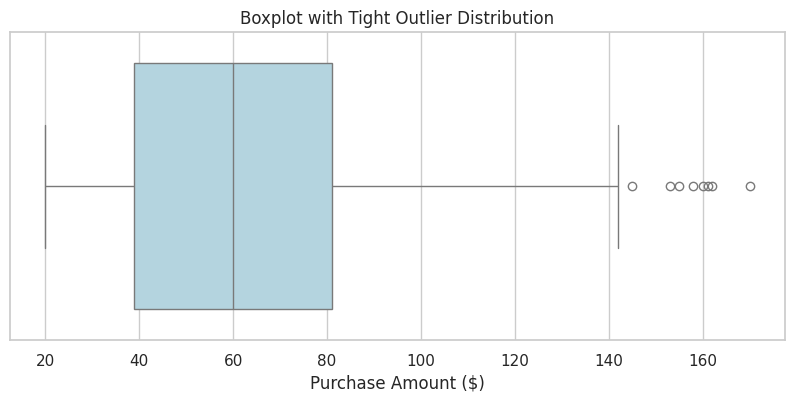

In [44]:
# Create a copy so we don't mess up the original data
df_with_outliers = df.copy()

# Adding outliers to understand how to fix the data
outlier_values = [120, 133, 135, 158, 142, 145, 170, 155, 160, 153, 162, 161]

for i, value in enumerate(outlier_values):
    df_with_outliers.at[i, 'Purchase Amount (USD)'] = value

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_with_outliers['Purchase Amount (USD)'], color='lightblue')
plt.title("Boxplot with Tight Outlier Distribution")
plt.xlabel("Purchase Amount ($)")
plt.show()

In [47]:
#Showing the details of the 'fake' outliers we created.
for i, value in enumerate(outlier_values):
    df_with_outliers.at[i, 'Purchase Amount (USD)'] = value

Q1 = df_with_outliers['Purchase Amount (USD)'].quantile(0.25)
Q3 = df_with_outliers['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_with_outliers[(df_with_outliers['Purchase Amount (USD)'] < lower) | (df_with_outliers['Purchase Amount (USD)'] > upper)]

print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print(f"Outliers found: {len(outliers)}")
outliers.head(len(outlier_values))

Lower Bound: -24.0
Upper Bound: 144.0
Outliers found: 8


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
3,4,21,Male,Sandals,Footwear,158,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
5,6,46,Male,Sneakers,Footwear,145,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,170,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,155,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,160,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,153,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly
10,11,53,Male,Shoes,Footwear,162,Arkansas,L,Purple,Fall,4.1,Yes,Yes,26,Bank Transfer,Bi-Weekly
11,12,30,Male,Shorts,Clothing,161,Hawaii,S,Olive,Winter,4.9,Yes,Yes,10,Bank Transfer,Fortnightly


In [49]:
df_no_outliers = df_with_outliers[(df_with_outliers['Purchase Amount (USD)'] >= lower) & (df_with_outliers['Purchase Amount (USD)'] <= upper)]
print("Original shape: ", df_with_outliers.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:  (3900, 16)
After removing outliers:  (3892, 16)


In [53]:
lower_cap = df['Purchase Amount (USD)'].quantile(0.05)
upper_cap = df['Purchase Amount (USD)'].quantile(0.95)
df_capped = df.copy()
df_capped['Purchase Amount (USD)'] = df_capped['Purchase Amount (USD)'].clip(lower_cap, upper_cap)

In [57]:
df[['Purchase Amount (USD)', 'Previous Purchases']].head()

,Purchase Amount (USD),Previous Purchases
0,53,14
1,64,2
2,73,23
3,90,49
4,49,31


In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Purchase Amount (USD)', 'Previous Purchases']].copy()

df_scaled[['Purchase Amount (USD)', 'Previous Purchases']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Purchase Amount (USD),Previous Purchases
0,0.4125,0.265306
1,0.5500,0.020408
2,0.6625,0.448980
3,0.8750,0.979592
4,0.3625,0.612245


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Purchase Amount (USD)', 'Previous Purchases']].copy()

df_standardized[['Purchase Amount (USD)', 'Previous Purchases']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Purchase Amount (USD),Previous Purchases
0,-0.285629,-0.785831
1,0.178852,-1.616552
2,0.558882,-0.162789
3,1.276716,1.637107
4,-0.454531,0.391025


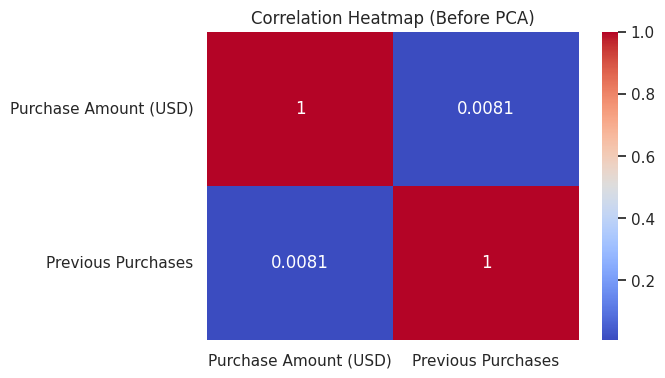

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Purchase Amount (USD)', 'Previous Purchases']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [65]:
from sklearn.decomposition import PCA
X = df_standardized[['Purchase Amount (USD)', 'Previous Purchases']]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50403171 0.49596829]


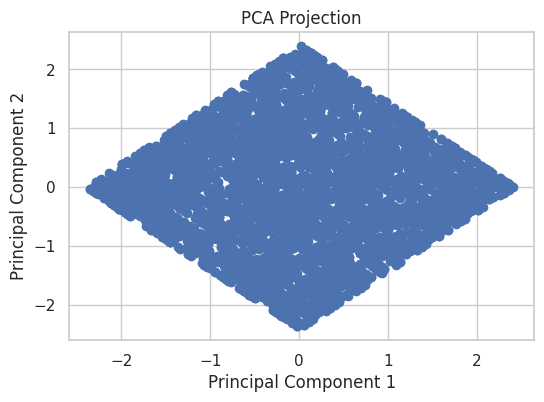

In [67]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()